# <span style="color: purple;">Lesson 2 - Your First Machine Learning Model</span>

**Developers:** Brian &nbsp;|&nbsp; **Reviewers:** Alina, Mungo

---

By the end of this lesson, **you'll have built and trained your own AI model**.

<div class="alert alert-info">

**How it works:** Click the ▶ button on each cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

---

## <span style="color: purple;">🧩 What is Classification?</span>

Your phone’s spam filter, Netflix recommendations, and face unlock all use the same idea: a computer that learns to sort things into groups.

We call this **classification**. Instead of being told the rules, the computer learns from examples. Show it enough data and it figures out the pattern itself.

Here are some everyday examples:

| Thing to sort | What gets measured | What it predicts |
|-------|--------------------|-----------------|
| 📧 Email | Words, sender, links | **Spam** or **Inbox** |
| 📸 Medical scan | Shapes, brightness | **Healthy** or **Tumour** |
| 🎮 Gamer | Time played, wins | **Pro** or **Noob** |
| 🖼️ Animal photo | Colour, ear shape, size | **Cat**, **Dog**, or **Horse** |

---

## <span style="color: purple;">Step 1 - Look at the data</span>

We're going to teach a computer to identify three species of iris flower just from their measurements.

The dataset has **150 flowers**. Each one has 4 measurements, known as **features**, and a **label** saying which species it is.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Petal-sepal.jpg/500px-Petal-sepal.jpg" alt="Petal and Sepal Diagram" width="250" style="margin-top:10px; margin-bottom:15px; border-radius: 8px;"/>

| Measurement | Example value |
|-------------|--------------|
| Sepal length (cm) | 5.1 |
| Sepal width (cm) | 3.5 |
| Petal length (cm) | 1.4 |
| Petal width (cm) | 0.2 |

The 3 species we're trying to predict:

|*Species 1*|*Species 2*|*Species 3*|
|:---:|:---:|:---:|
| **Setosa** | **Versicolor** | **Virginica** |
| <img src="https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg" alt="Iris Setosa" width="200"/> | <img src="https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg" alt="Iris Versicolor" width="200"/> | <img src="https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg" alt="Iris Virginica" width="200"/> |

<div class="alert alert-info">

**Run the cell below** to load the data and plot it.

</div>

Dataset shape: (150, 5)  →  150 rows, 5 columns


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


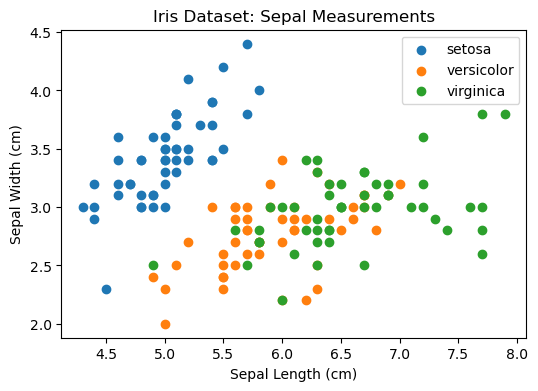

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
iris = load_iris()

# Put it in a DataFrame so it's easy to read
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]   # add the label column

print(f"Dataset shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

# Plot Sepal Length vs Sepal Width
plt.figure(figsize=(6, 4))
for i, species in enumerate(iris.target_names):
    subset = df[df['species'] == species]
    plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], label=species)
plt.title('Iris Dataset: Sepal Measurements')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.show()

<div class="alert alert-info">

### 👀 What are we looking at?

- **The table** shows the first 5 flowers. Each row is one flower, with its measurements and species label.

- **The plot** shows all 150 flowers. Each dot is one flower, coloured by species. Notice how the setosa flowers (blue) are clearly separated from the others. The model's job is to learn these boundaries automatically.

</div>

---

## <span style="color: purple;">Step 2 - Train the model</span>

Now we feed the data to a model and it learns in seconds.

Don't worry about understanding every line yet. Focus on what happens when you run it.

In [2]:
from sklearn.model_selection import train_test_split

X = iris.data    # features  (the 4 measurements)
y = iris.target  # labels    (species codes: 0, 1, or 2)

# 80% training data, 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)} flowers")
print(f"Test samples     : {len(X_test)} flowers")

from sklearn.tree import DecisionTreeClassifier

# 1. Create the model (a Decision Tree)
model = DecisionTreeClassifier(random_state=42)

# 2. Train it, this is where the 'learning' happens
model.fit(X_train, y_train)

print("\nModel successfully trained!")

Training samples : 120 flowers
Test samples     : 30 flowers

Model successfully trained!


<div class="alert alert-info">

### 🎉 There you go, you have successfully trained your first machine learning model!

We have:

* Split the data into a training dataset, and a testing dataset
* Made a model
* **Trained** the model to learn patterns in the iris dataset


You may have noticed that only 120 out of 150 flowers were used for training the model. There is a reason for this - keep going to find out.

</div>

---

## <span style="color: purple;">Step 3 - Test the model</span>

We held back 30 flowers the model has never seen. Now we ask it to guess their species.

Think of it like a test at school, you can only find out if someone really learned something by asking them questions they haven't seen before.

In [7]:
from sklearn.metrics import accuracy_score

# Ask the model to guess the species of the 30 unseen flowers
y_pred = model.predict(X_test)

# Compare guesses to the real answers
accuracy = accuracy_score(y_test, y_pred)
print(f"Number of correct guesses: {(y_pred == y_test).sum()} out of {len(y_test)}")
print(f"Model accuracy: {accuracy * 100:.1f}%")

print("\nFirst 10 guesses vs. real answers:")

label_comparison = pd.DataFrame({
    'Predicted': iris.target_names[y_pred[:10]],
    'Actual': iris.target_names[y_test[:10]]
})
display(label_comparison)

Number of correct guesses: 30 out of 30
Model accuracy: 100.0%

First 10 guesses vs. real answers:


,Predicted,Actual
0,versicolor,versicolor
1,setosa,setosa
2,virginica,virginica
3,versicolor,versicolor
4,versicolor,versicolor
5,setosa,setosa
6,versicolor,versicolor
7,virginica,virginica
8,versicolor,versicolor
9,versicolor,versicolor


<div class="alert alert-info">

### ⁉️ Wait - 100%?

These three flower species happen to be very easy to tell apart from their measurements, so 100% is possible here. In the real world, you'll almost never see this. If you do, it's usually a sign something went wrong (like the model accidentally got to see the test answers during training).

</div>

---

## <span style="color: purple;">🧠 What did we just do?</span>

| Word | What it means |
|------|--------------|
| **Classification** | Sorting things into groups (e.g. which species?) |
| **Features** | The measurements we use to make the prediction |
| **Label** | The correct answer (the species name) |
| **Training** | Showing the model examples so it can learn the pattern |
| **Prediction** | The model's guess on a flower it hasn't seen |
| **Accuracy** | The percentage of guesses that were correct |

The key rule: **always test on data the model hasn't trained on.** Testing on the same data it learned from would be like marking your own homework.

---

## <span style="color: purple;">🔧 Your turn!</span>

The model trained on 80% of the flowers (`test_size=0.2` means 20% was kept for testing).

**Change `test_size` below and re-run. What happens to the accuracy?**

In [4]:
# 🔧 Change test_size below and re-run this cell to see what happens!
test_size = 0.2   # ← try 0.3, 0.4, or 0.5

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=test_size, random_state=42)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

print(f"Training on {int((1 - test_size) * 100)}% of data → Accuracy: {accuracy_score(y_test2, y_pred2) * 100:.1f}%")

Training on 80% of data → Accuracy: 100.0%
